In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Titanic-Dataset.csv')

In [3]:
# prinitng first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# prinitng all columns
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
# showing details of all columns with respect to their datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df = df.drop(['Cabin'], axis=1)

In [7]:
# finding null values in the dataset
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [8]:
# dropping null values........
df1=df.dropna()

In [9]:
df1.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Text(0.5, 1.0, 'Passenger Survival Count')

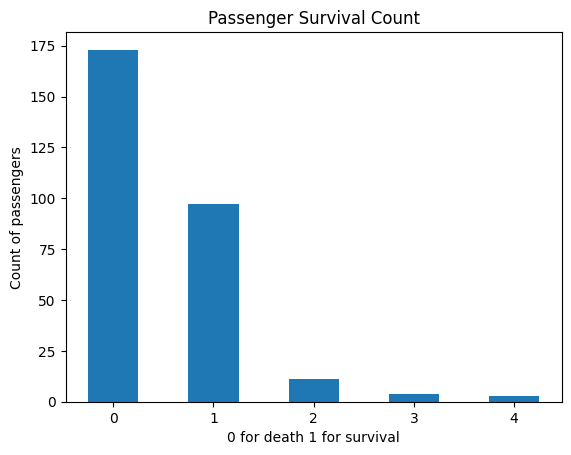

In [10]:
dataset=df1[(df1['Survived']==1)]
plt.bar(dataset['SibSp'].value_counts().index,dataset['SibSp'].value_counts(),width=0.5)
plt.xlabel("0 for death 1 for survival")
plt.ylabel("Count of passengers")
plt.title("Passenger Survival Count")

In [11]:
df1['Survived'].unique()

array([0, 1], dtype=int64)

Text(0.5, 1.0, 'Passenger Survival Count')

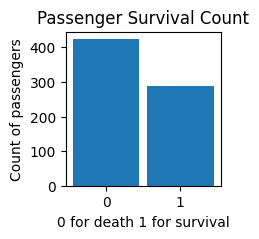

In [12]:
plt.figure(figsize=(2,2))
plt.bar(df1['Survived'].value_counts().index,df1['Survived'].value_counts(),width=0.9)
plt.xlabel("0 for death 1 for survival")
plt.ylabel("Count of passengers")
plt.title("Passenger Survival Count")

Text(0.5, 1.0, 'Survival by Gender')

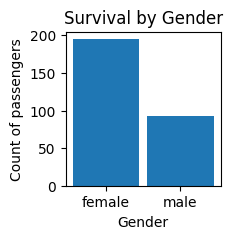

In [13]:
dataset=df1[(df1['Survived']==1)]
plt.figure(figsize=(2,2))
plt.bar(dataset['Sex'].value_counts().index,dataset['Sex'].value_counts(),width=0.9)
plt.xlabel("Gender")
plt.ylabel("Count of passengers")
plt.title("Survival by Gender")

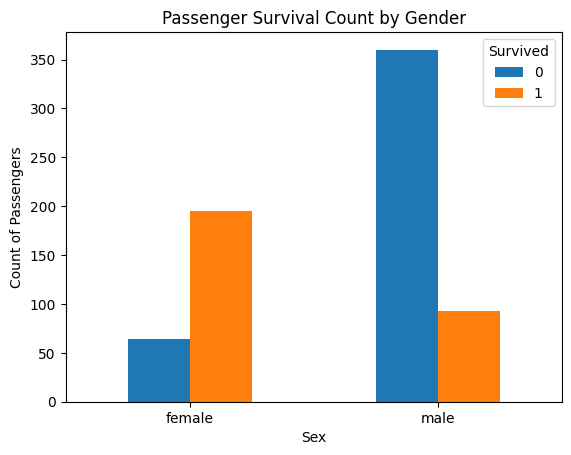

In [14]:
import matplotlib.pyplot as plt

survival_counts = df1.groupby(['Sex', 'Survived']).size().unstack(fill_value=0)

survival_counts.plot(kind='bar', width=0.5)

plt.xlabel("Sex")
plt.ylabel("Count of Passengers")
plt.title("Passenger Survival Count by Gender")
plt.xticks(rotation=0)  # Makes the x-axis labels more readable

# Show the plot
plt.show()


Text(0.5, 1.0, 'Passenger Survival Count')

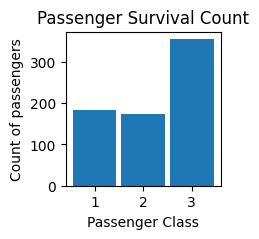

In [15]:
plt.figure(figsize=(2,2))
plt.bar(df1['Pclass'].value_counts().index,df1['Pclass'].value_counts(),width=0.9)
plt.xlabel("Passenger Class")
plt.ylabel("Count of passengers")
plt.title("Passenger Survival Count")

Text(0.5, 1.0, 'Passenger Survival Count')

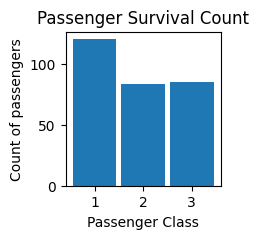

In [16]:
plt.figure(figsize=(2,2))
dataset=df1[(df1['Survived']==1)]
plt.bar(dataset['Pclass'].value_counts().index,dataset['Pclass'].value_counts(),width=0.9)
plt.xlabel("Passenger Class")
plt.ylabel("Count of passengers")
plt.title("Passenger Survival Count")

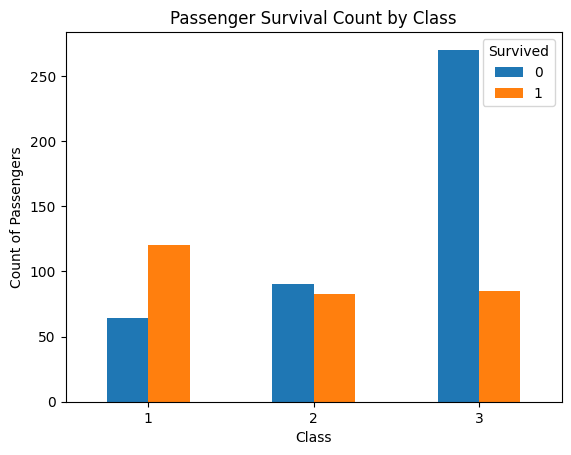

In [17]:
import matplotlib.pyplot as plt

survival_counts = df1.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)

survival_counts.plot(kind='bar', width=0.5)

plt.xlabel("Class")
plt.ylabel("Count of Passengers")
plt.title("Passenger Survival Count by Class")
plt.xticks(rotation=0)  # Makes the x-axis labels more readable

# Show the plot
plt.show()


Text(0.5, 1.0, 'Count of Passengers')

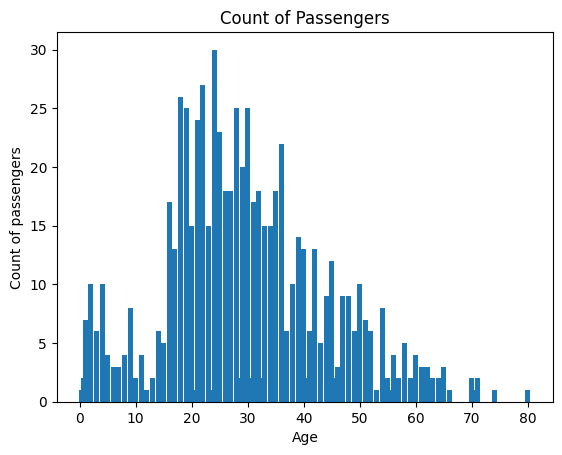

In [18]:
plt.bar(df1['Age'].value_counts().index,df1['Age'].value_counts(),width=0.9)
plt.xlabel("Age")
plt.ylabel("Count of passengers")
plt.title("Count of Passengers")

Text(0.5, 1.0, 'Passenger Survival Count')

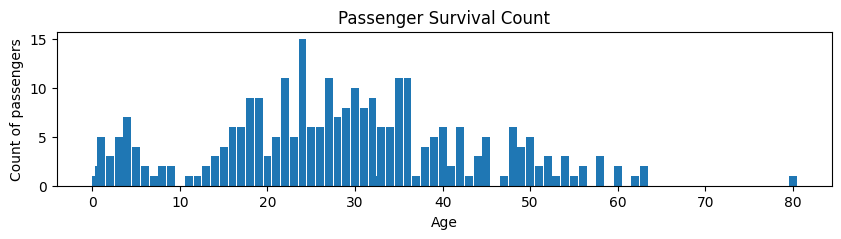

In [19]:
dataset=df1[(df1['Survived']==1)]
plt.figure(figsize=(10,2))
plt.bar(dataset['Age'].value_counts().index,dataset['Age'].value_counts(),width=0.9)
plt.xlabel("Age")
plt.ylabel("Count of passengers")
plt.title("Passenger Survival Count")

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Assuming your dataframe is named 'df'
predictors = df.drop(['Survived', 'PassengerId', 'Name'], axis=1)
target = df["Survived"]

# One-hot encode categorical features
predictors = pd.get_dummies(predictors)

# Split data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(predictors, target, test_size=0.2, random_state=0)

# Initialize RandomForestClassifier
randomforest = RandomForestClassifier()

# Fit the model
randomforest.fit(x_train, y_train)

# Make predictions
y_pred = randomforest.predict(x_val)

# Calculate accuracy
acc_randomforest = round(accuracy_score(y_pred, y_val) * 100, 2)
print(f"Accuracy of Random Forest: {acc_randomforest}%")


Accuracy of Random Forest: 82.52%
